<a href="https://colab.research.google.com/github/goldedan7/robot-dynamics/blob/main/P1_Pendulum_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np                          # numerical arrays & maths
import matplotlib.pyplot as plt             # plotting
from scipy.integrate import solve_ivp       # ODE solver

print("✓ Libraries ready")


✓ Libraries ready


In [3]:
g = 9.81      # gravitational acceleration (m/s^2)
L = 1.0       # pendulum length (m)
b = 0.3       # damping coefficient (air resistance / joint friction)

print(f"{L} m pendulum, gravity {g}, damping {b}")


1.0 m pendulum, gravity 9.81, damping 0.3


In [4]:
def pendulum(t, state, damping):
    """
    Nonlinear pendulum dynamics in state-space form.

    t       : time (required by the solver's call signature; unused here,
              because the pendulum's physics don't depend on time directly)
    state   : [theta, omega] — angle (rad) and angular velocity (rad/s)
    damping : friction / air-resistance coefficient

    Returns d/dt[theta, omega].
    """
    theta, omega = state
    dtheta = omega
    domega = -(g / L) * np.sin(theta) - damping * omega
    return [dtheta, domega]


# Quick check: released from rest at 45 degrees, with damping 0.3
test = pendulum(0, [np.radians(45), 0], 0.3)
print(f"At 45 deg, released from rest: dtheta={test[0]:.2f}, domega={test[1]:.2f}")

At 45 deg, released from rest: dtheta=0.00, domega=-6.94


In [5]:
# Initial state: released from rest at 60 degrees
initial = [np.radians(60), 0.0]

# Record 1000 time points from 0 to 20 seconds
t_eval = np.linspace(0, 20, 1000)

# Integrate forward in time.
# args=(0.3,) passes damping=0.3 as the function's 3rd argument.
sol = solve_ivp(pendulum, (0, 20), initial,
                t_eval=t_eval, method='RK45', args=(0.3,))

theta = sol.y[0]    # angle history
omega = sol.y[1]    # angular velocity history
t = sol.t           # time stamps

print(f"✓ Simulation complete — {len(t)} time points")
print(f"  Start : {np.degrees(theta[0]):.1f} deg")
print(f"  End   : {np.degrees(theta[-1]):.1f} deg  (settled near 0 — damping worked)")

✓ Simulation complete — 1000 time points
  Start : 60.0 deg
  End   : 1.6 deg  (settled near 0 — damping worked)


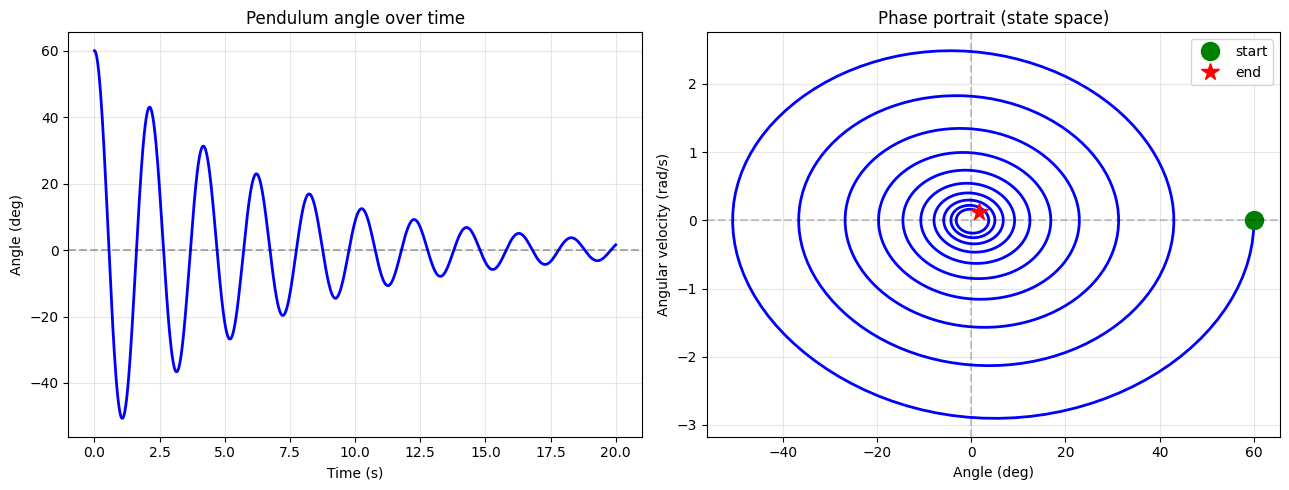

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5)) ###graph###

# -- Left: angle over time ------
ax1.plot(t, np.degrees(theta), 'b-', linewidth=2)
ax1.axhline(0, color = 'k', linestyle='--', alpha= 0.3)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Angle (deg)')
ax1.set_title('Pendulum angle over time')
ax1.grid(alpha=0.3)

#-- Right: phase portrait ------
ax2.plot(np.degrees(theta), omega, 'b-', linewidth=2)
ax2.plot(np.degrees(theta[0]), omega[0], 'go', markersize=13, label='start')
ax2.plot(*[np.degrees(theta[-1]), omega[-1]], 'r*', markersize=13, label='end')
ax2.axhline(0,linestyle='--', color='k', alpha=0.2)
ax2.axvline(0, linestyle='--', color='k', alpha=0.2)
ax2.set_xlabel('Angle (deg)')
ax2.set_ylabel('Angular velocity (rad/s)')
ax2.set_title('Phase portrait (state space)')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()


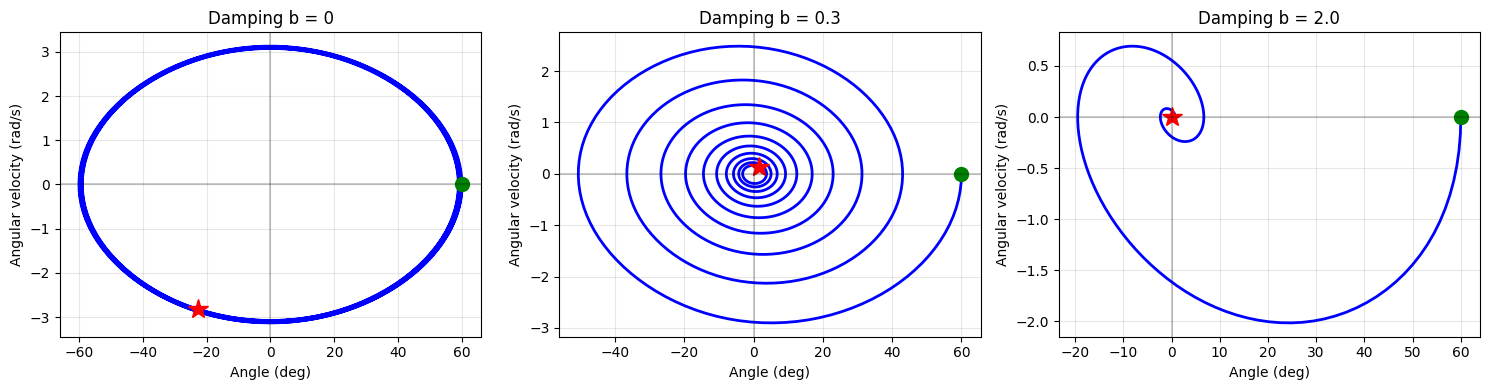

Observations:
  b=0   : closed loop → no energy lost → swings forever
  b=0.3 : spiral inward → settles down gradually
  b=2.0 : tight spiral → settles down quickly


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
b_values = [0, 0.3, 2.0]

for i, b_test in enumerate(b_values):
    sol_test = solve_ivp(pendulum, (0, 20), initial,
                          t_eval=t_eval, method='RK45', args=(b_test,))
    theta_test = sol_test.y[0]
    omega_test = sol_test.y[1]

    axes[i].plot(np.degrees(theta_test), omega_test, 'b-', linewidth=2)
    axes[i].plot(np.degrees(theta_test[0]), omega_test[0], 'go', markersize=10)
    axes[i].plot(np.degrees(theta_test[-1]), omega_test[-1], 'r*', markersize=15)
    axes[i].axhline(0, color='k', alpha=0.2)
    axes[i].axvline(0, color='k', alpha=0.2)
    axes[i].set_xlabel('Angle (deg)')
    axes[i].set_ylabel('Angular velocity (rad/s)')
    axes[i].set_title(f'Damping b = {b_test}')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Observations:")
print("  b=0   : closed loop → no energy lost → swings forever")
print("  b=0.3 : spiral inward → settles down gradually")
print("  b=2.0 : tight spiral → settles down quickly")